# Assessment Task 1
## Section 2(a): ANN Classifier with LBP
### 1. Extract files and Install all required dependencies and 

In [1]:
!unzip student_25349642.zip

Archive:  student_25349642.zip
replace student_25349642/+/+_100242.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [1]:
!pip install opencv-python-headless

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4━━━━━ 0/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python-headless]v-python-headless]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not in

In [3]:
!pip install split-folders

In [4]:
import splitfolders

splitfolders.ratio("student_25349642", output="output", seed=1337, ratio=(.8, .1, .1),
                   group_prefix=None, group=None, formats=(".jpg", ".jpeg", ".png"), move=False, shuffle=True)

Copying files: 5000 files [00:04, 1128.88 files/s]


### 2. Dataset Preparation

**Finish writing in the section headings AFTER completing all the code**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature # This pacakge is used for LBP feature extraction
from sklearn import svm # This pacakge is used for svm classification
from sklearn import metrics
%matplotlib inline
import cv2
import seaborn as sns # This pacakge is used for better visualization of data (e.g confusion matrix)
import os
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skimage import feature

In [3]:
labelName = ['+', 'beta', 'cos', 'leq', 'M', 'N', 'R', 'rightarrow', 'S', 'z']

def load_dataset(path):

    data = []
    labels = []

    for label in labelName:
        class_path = os.path.join(path, label)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (28, 28))

            data.append(img.flatten())
            labels.append(labelName.index(label))
            
    return np.array(data), np.array(labels)

In [4]:
X_train, y_train = load_dataset('./output/train')
X_test, y_test = load_dataset('./output/test')
X_val, y_val = load_dataset('./output/val')

In [5]:
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_val))

(4000, 784)
(500, 784)
(500, 784)


In [6]:
X_train=X_train.reshape(-1,28,28)
X_test=X_test.reshape(-1,28,28)
X_val=X_val.reshape(-1,28,28)

# print the size of the result reshaped train and test data splits

print("Train dataset after reshaping:{}".format(np.shape(X_train)))
print("Test dataset after reshaping :{}".format(np.shape(X_test)))
print("Val dataset after reshaping :{}".format(np.shape(X_val)))

Train dataset after reshaping:(4000, 28, 28)
Test dataset after reshaping :(500, 28, 28)
Val dataset after reshaping :(500, 28, 28)


+
cos
rightarrow
rightarrow


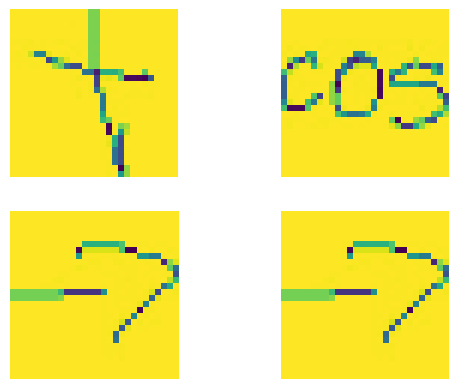

In [7]:
img_index = 10
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.axis('off')
ax1.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,2)
ax2.axis('off')
img_index = 1000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,3)
ax2.axis('off')
img_index = 3000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,4)
ax2.axis('off')
img_index = 3000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

In [8]:
class LocalBinaryPatterns:
	def __init__(self, numPoints, radius):
		# store the number of points and radius
		self.numPoints = numPoints
		self.radius = radius

	def LBPfeatures(self, image, eps=1e-7):
		# compute the Local Binary Pattern representation
		# of the image, and then use the LBP representation
		# to build the histogram of patterns
		lbp = feature.local_binary_pattern(image, self.numPoints,
			self.radius, method="uniform")
    # Form the histogram
		(hist, _) = np.histogram(lbp.ravel(),
			bins=np.arange(0, self.numPoints + 3),
			range=(0, self.numPoints + 2))

		# normalize the histogram
		hist = hist.astype("float")
		hist /= (hist.sum() + eps)

		# return the histogram of Local Binary Patterns
		return hist

In [9]:
# Create an object of LocalBinaryPatterns class and initial the parameters.
desc = LocalBinaryPatterns(24, 8)
data_train_lbp = []
labels_train_lbp = []

## WRITE YOUR CODE HERE (~ 3 lines)
# loop over the training images
for img_index in range(len(X_train)):
	# load the train image, and extract LBP features
	image = (X_train[img_index])
	hist = desc.LBPfeatures(image)
## END YOUR CODE HERE

	# extract the label from the image path, then update the
	# label and data lists
	labels_train_lbp.append(y_train[img_index])
	data_train_lbp.append(hist)

data_train_lbp = np.array(data_train_lbp).T
labels_train_lbp = np.array(labels_train_lbp)
    
## END YOUR CODE HERE ##
print(np.shape(data_train_lbp))
print(np.shape(labels_train_lbp))

(26, 4000)
(4000,)


In [10]:
data_val_lbp = []
labels_val_lbp = []

for img_index in range(len(X_val)):
    image = X_val[img_index]
    hist = desc.LBPfeatures(image)

    data_val_lbp.append(hist)
    labels_val_lbp.append(y_val[img_index])
    
data_val_lbp = np.array(data_val_lbp).T
labels_val_lbp = np.array(labels_val_lbp)

In [11]:
def softmax(z):
    """
    Returns the sigmoid of z

    Arguments:
    z --> A scalar or numpy array of any size.

    Return:
    s --> sigmoid(z)
    """

    ### WRITE YOUR CODE HERE ### (~ 2 line of code)

    z_max = np.max(z, axis=0, keepdims=True)
    z_exp = np.exp(z - z_max)
    s = z_exp / np.sum(z_exp, axis=0, keepdims=True)

    ### END YOUR CODE HERE ###

    return s

In [12]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

In [13]:
def loss(A, Y, m):

  """
    Returns the average log loss of A and Y

    Arguments:
    A --> A numpy array of any size.
    Y --> A numpy array of any size.
    m --> number of samples

    Return:
    loss(A, Y, m) --> a scalar
  """

  ## WRITE YOUR CODE HERE ## (~ 1 line of code)

  return (1 / m) * np.sum((-Y) * np.log(A + 1e-10))

  ### END YOUR CODE HERE ###

In [14]:
def initialize_weight_bias(n_x, n_h, n_y):
  """
  Initialize the weight (W) and bias (b) for ReLU and Softmax functions

  return w1, b1, w2 and b2
  """
  ## WRITE YOUR CODE HERE ## (~ 2 line of code)
  np.random.seed(1)
  w1 = np.random.randn(n_h, n_x) * 0.01
  b1 = np.zeros((n_h, 1))
  w2 = np.random.randn(n_y, n_h) * 0.01
  b2 = np.zeros((n_y, 1))
  ### END YOUR CODE HERE ###

  return w1, b1, w2, b2

In [15]:
def gradient_descent(w1, b1, w2, b2, X, Y, epochs, learning_rate, show_cost = True):
    """
    Gradient Descent (GD) Algorithm to find the optimum value of W and B

    Arguments:
    w --> weights, a numpy array of size (num_px * num_px * 3, 1)
    b --> bias, a scalar
    X --> data of shape (num_px * num_px * 3, number of examples)
    Y --> true "label" vector (containing 0 if non-cat, 1 if cat), of shape (1, number of examples)
    num_iterations --> number of iterations of the GD loop
    learning_rate --> learning rate of the gradient descent update rule
    show_cost --> True to displat the loss at every 1000 steps

    Returns:
    params --> dictionary containing the weights w and bias b
    grads --> dictionary containing the gradients of the weights and bias with respect to the cost function
    costs --> list of all the costs computed during the optimization, this will be used to plot the learning curve.

    Tips:
    You basically need to write down two steps and iterate through them:
        1) Calculate the cost and the gradient for the current parameters. Use propagate().
        2) Update the parameters using gradient descent rule for w and b.
    """

    costs = []

    for itr in range(epochs):


        # FORWARD PASS Operation: Cost and gradient calculation
        ## WRITE YOUR CODE HERE ## (~ 2 line of code)

        m = X.shape[1]

        z1 = np.dot(w1, X) + b1
        a1 = relu(z1)

        z2 = np.dot(w2, a1) + b2
        a2 = softmax(z2)

        cost = loss(a2, Y, m)
        
        ### END YOUR CODE HERE ###

        # BACK PROPAGATION Operation (Find gradient(dw), dw and db)
        ## WRITE YOUR CODE HERE ## (~ 3 line of code)

        dz2 = (a2 - Y)
        dw2 = (1 / m) * np.dot(dz2, a1.T)
        db2 = (1 / m) * np.sum(dz2, axis=1, keepdims=True)

        dz1 = np.dot(w2.T, dz2) * relu_derivative(z1)
        dw1 = (1 / m) * np.dot(dz1, X.T)
        db1 = (1 / m) * np.sum(dz1, axis=1, keepdims=True)

        ### END YOUR CODE HERE ###

        cost = np.squeeze(cost)

        # Update w and b with dw and db
        # Hint:
        # dw = dw - learning_rate *dw
        # db = db - learning_rate *db
        ## WRITE YOUR CODE HERE ## (~ 2 line of code)

        w1 = w1 - (learning_rate * dw1)
        b1 = b1 - (learning_rate * db1)
        w2 = w2 - (learning_rate * dw2)
        b2 = b2 - (learning_rate * db2)

        ### END YOUR CODE HERE ###
        #print ("Cost after %i epochs: %f" %(itr, cost))

        # Record the costs after 100 interations
        if itr % 10 == 0:
            costs.append(cost)

        # Print the cost every 100 training examples
        if (show_cost and itr % 100 == 0):
            print (f"Cost after {itr} epochs: {cost:.4f}")

    params = {"w1": w1,
              "b1": b1,
              "w2" : w2,
              "b2" : b2}

    grads = {"dw1": dw1,
             "db1": db1,
             "dw2": dw2,
             "db2": db2}

    return params, grads, costs

In [16]:
def predict(params, X):
    '''
    Predict whether the label is 0 or 1 using logistic regression parameters (w, b) learned using Gradient Descent(GD)

    Arguments:
    wOptimum --> weights, a numpy array of size (num_px * num_px * 3, 1)
    bOptimum --> bias, a scalar
    XTest --> data of size (num_px * num_px * 3, number of examples)

    Returns:
    Y_prediction --> a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''

    ## WRITE YOUR CODE HERE ## (~ 1 line of code)

    w1, b1 = params["w1"], params["b1"]
    w2, b2 = params["w2"], params["b2"]

    z1 = np.dot(w1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = softmax(z2)
    
    ### END YOUR CODE HERE ###

    return np.argmax(a2, axis=0)



In [17]:
def fit(X_train, y_train, epochs = 2000, learning_rate = 0.5, show_cost = False):
    """
    Builds the logistic regression model by calling the functions we have implemented previously

    Arguments:
    X_train --> training set represented by a numpy array of shape (num_px * num_px * 3, m_train)
    Y_train --> training labels represented by a numpy array (vector) of shape (1, m_train)
    num_iterations --> hyperparameter representing the number of iterations to optimize the parameters
    learning_rate --> hyperparameter representing the learning rate used in the update rule of optimize()
    show_cost --> Set to true to display the cost every 100 iterations

    Returns:
    model --> dictionary containing information (costs, Y_prediction_train, w, b, learning_rate,num_iteration) about the model.
    """

    ### START CODE HERE ###

    # Collect number of classes first
    num_classes = len(np.unique(y_train))

    def one_hot(y, num_classes):
        m = y.shape[0]
        one_hot_Y = np.zeros((num_classes, m))
        one_hot_Y[y, np.arange(m)] = 1
        return one_hot_Y
    
    Y_train = one_hot(y_train, num_classes)

    n_x = X_train.shape[0]
    n_h = 64
    n_y = num_classes
    
    
    # initialize parameters with zeros (~ 1 line of code)
    w1, b1, w2, b2 = initialize_weight_bias(n_x, n_h, n_y)

    # Gradient descent (~ 1 line of code)
    parameters, grads, costs = gradient_descent(w1, b1, w2, b2, X_train, Y_train, epochs, learning_rate, show_cost=show_cost)

    # Predict train set samples (~ 1 lines of code)
    y_prediction_train = predict(parameters, X_train)

    ### END CODE HERE ###

    # Print train/test Errors
    train_accuracy = np.mean(y_prediction_train == y_train) * 100
    print(f"train accuracy: {train_accuracy:.2f} %")


    model = {"params": parameters,
             "costs": costs,
             "learning_rate": learning_rate,
             "num_iterations": epochs}

    return model

In [18]:
def extract_LBP_features(X):
    features_list_lbp = []
    for img in X:
        hist = desc.LBPfeatures(img)
        features_list_lbp.append(hist)
    return np.array(features_list_lbp).T
        
X_train_lbp = extract_LBP_features(X_train)
X_test_lbp  = extract_LBP_features(X_test)

X_train_lbp = X_train_lbp / np.max(X_train_lbp, axis=0, keepdims=True)
X_test_lbp  = X_test_lbp / np.max(X_test_lbp, axis=0, keepdims=True)

mean = np.mean(X_train_lbp, axis=1, keepdims=True)
std = np.std(X_train_lbp, axis=1, keepdims=True) + 1e-7

X_train_lbp = (X_train_lbp - mean) / std
X_test_lbp  = (X_test_lbp - mean) / std

model_lbp = fit(X_train_lbp, y_train, epochs=2000, learning_rate=0.5, show_cost=True)

## Retrieve w and b from the trained model for prediction
y_prediction_test_lbp = predict(model_lbp["params"], X_test_lbp)

%time
## Call predict() to test the samples in testset
train_accuracy = np.mean(y_prediction_test_lbp == y_test) * 100
print(f"train accuracy: {train_accuracy:.2f} %")

Cost after 0 epochs: 2.3028
Cost after 100 epochs: 1.4481
Cost after 200 epochs: 1.2158
Cost after 300 epochs: 1.0852
Cost after 400 epochs: 0.9983
Cost after 500 epochs: 0.9350
Cost after 600 epochs: 0.8822
Cost after 700 epochs: 0.8370
Cost after 800 epochs: 0.7970
Cost after 900 epochs: 0.7615
Cost after 1000 epochs: 0.7292
Cost after 1100 epochs: 0.6993
Cost after 1200 epochs: 0.6711
Cost after 1300 epochs: 0.6449
Cost after 1400 epochs: 0.6266
Cost after 1500 epochs: 0.6103
Cost after 1600 epochs: 0.5947
Cost after 1700 epochs: 0.5810
Cost after 1800 epochs: 0.5670
Cost after 1900 epochs: 0.5531
train accuracy: 83.23 %
CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 25.7 μs
train accuracy: 71.00 %


In [19]:
def plotLearningCurve(model_lbp):
  """
  Helper function to plot the Learning curve

  Argument : model (learned paramenters and costs)
  """

  plt.plot(model_lbp["costs"])
  plt.ylabel('cost')
  plt.xlabel('iterations (per hundreds)')
  plt.title("Cost/Loss Curve")
  plt.show()


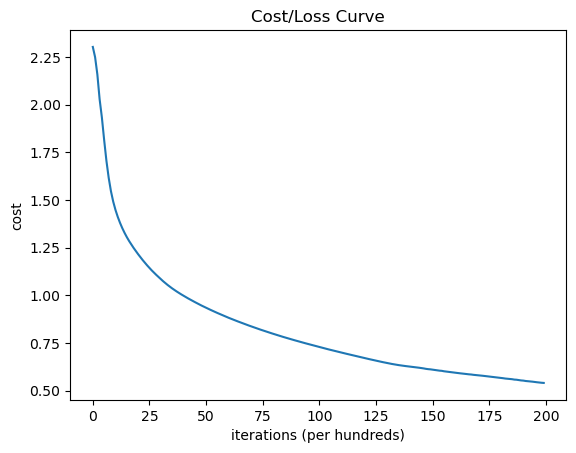

In [20]:
plotLearningCurve(model_lbp)

In [21]:
accuracy_lbp = accuracy_score(y_test, y_prediction_test_lbp)
print("Accuracy on test dataset:", accuracy_lbp)

Accuracy on test dataset: 0.71


[[45  0  0  3  0  0  0  2  0  0]
 [ 0 43  1  1  0  3  1  0  0  1]
 [ 0  1 44  1  0  0  1  0  2  1]
 [ 0  0  0 41  0  2  1  1  4  1]
 [ 0  6  4  3 17  9  3  1  4  3]
 [ 1  5  0  5  2 31  0  1  1  4]
 [ 1  2  1  1  2  4 33  0  2  4]
 [ 3  1  0  5  0  0  1 37  3  0]
 [ 0  1  0  1  2  3  0  2 37  4]
 [ 1  2  1  3  5  5  2  0  4 27]]


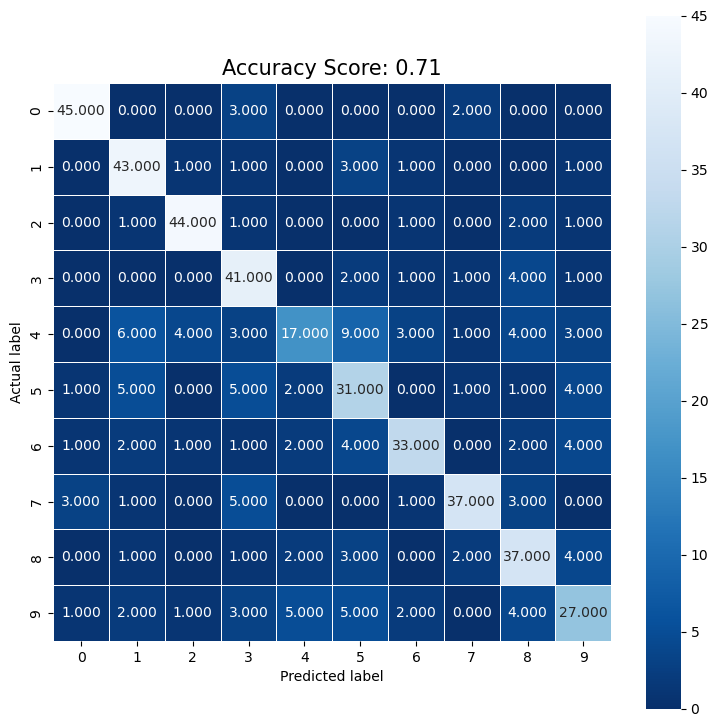

In [22]:
# plot the confusion matrix
cm_lbp  = metrics.confusion_matrix(y_test, y_prediction_test_lbp)
print(cm_lbp)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm_lbp, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_lbp)
plt.title(all_sample_title, size = 15);

In [23]:
# Display some classification result on test samples
images_lbp = []
pred_label_lbp = []
true_label_lbp = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  histo = X_test_lbp[:, i].reshape(-1, 1)
  prediction_lbp = predict(model_lbp["params"], histo.reshape(-1,1))[0]
  label_lbp = labelName[prediction_lbp]
  orig_label_lbp = labelName[y_test[i]]
  image = X_test[i]
  image = cv2.merge([image] * 3)
  image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

  # cv2.putText(image, f"Predicted Label: {label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 0), 2)
  # cv2.putText(image, f"True Label: {orig_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 0), 2)
    
  images_lbp.append(image)
  pred_label_lbp.append(label_lbp)
  true_label_lbp.append(orig_label_lbp)

In [24]:
np.shape(images_lbp[1])

(96, 96, 3)

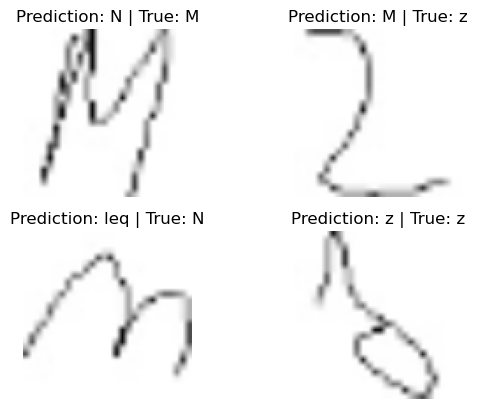

In [25]:
## Display the classification results
#Plot the image and the predicted labels
fig_lbp = plt.figure()
ax1 = fig_lbp.add_subplot(2,2,1)
ax1.imshow(images_lbp[0])
ax1.set_title(f"Prediction: {pred_label_lbp[0]} | True: {true_label_lbp[0]}")
ax1.axis("off")
ax2 = fig_lbp.add_subplot(2,2,2)
ax2.imshow(images_lbp[1])
ax2.set_title(f"Prediction: {pred_label_lbp[1]} | True: {true_label_lbp[1]}")
ax2.axis("off")
ax3 = fig_lbp.add_subplot(2,2,3)
ax3.imshow(images_lbp[2])
ax3.set_title(f"Prediction: {pred_label_lbp[2]} | True: {true_label_lbp[2]}")
ax3.axis("off")
ax4 = fig_lbp.add_subplot(2,2,4)
ax4.imshow(images_lbp[3])
ax4.set_title(f"Prediction: {pred_label_lbp[3]} | True: {true_label_lbp[3]}")
ax4.axis("off")
plt.show()

In [26]:
print("Test Accuracy: ", accuracy_score(y_test, y_prediction_test_lbp))

print(classification_report(y_test, y_prediction_test_lbp, target_names=labelName))

Test Accuracy:  0.71
              precision    recall  f1-score   support

           +       0.88      0.90      0.89        50
        beta       0.70      0.86      0.77        50
         cos       0.86      0.88      0.87        50
         leq       0.64      0.82      0.72        50
           M       0.61      0.34      0.44        50
           N       0.54      0.62      0.58        50
           R       0.79      0.66      0.72        50
  rightarrow       0.84      0.74      0.79        50
           S       0.65      0.74      0.69        50
           z       0.60      0.54      0.57        50

    accuracy                           0.71       500
   macro avg       0.71      0.71      0.70       500
weighted avg       0.71      0.71      0.70       500



# Assessment Task 1
## Section 2(b): ANN Classifier with HOG
### 1. Extract files and Install all required dependencies and 

In [27]:
# initialize the data matrix and labels
print("Extracting features from training dataset...")
data_train_hog = []
labels_train_hog = []

# loop over the training images
for img_index in range(len(X_train)):
  # load the image, and extract HOG features it
  ## WRITE YOUR CODE HERE ## (~ 4 lines)
  image = (X_train[img_index])

  # Hint: use orientation =9, pixel_per_cell=(10,10), cells_per_block=2,2,
  # transform_sqrt=True and block_norm="L2-Hys"
  #
  H = feature.hog(image, orientations=9, 
                  pixels_per_cell=(10,10), 
                  cells_per_block=(2,2), 
                  transform_sqrt=True, 
                  block_norm='L2-Hys') # Complete the code

  # update the data and labels
  data_train_hog.append(H) # Complete the code
  labels_train_hog.append(y_train[img_index]) # Complete the code

data_train_hog = np.array(data_train_hog).T
labels_train_hog = np.array(labels_train_hog)

## END YOUR CODE HERE ##
print(np.shape(data_train_hog))
print(np.shape(labels_train_hog))

Extracting features from training dataset...
(36, 4000)
(4000,)


In [28]:
data_val_hog = []
labels_val_hog = []

for img_index in range(len(X_val)):
    image = X_val[img_index]

    H = feature.hog(image,
                    orientations=9,
                    pixels_per_cell=(10,10),
                    cells_per_block=(2,2),
                    transform_sqrt=True,
                    block_norm='L2-Hys')

    data_val_hog.append(H)
    labels_val_hog.append(y_val[img_index])
data_val_hog = np.array(data_val_hog).T
labels_val_hog = np.array(labels_val_hog)

In [29]:
def extract_HOG_features(X):
    features_list_hog = []
    for img in X:
        H1 = feature.hog(img,
                         orientations=9,
                         pixels_per_cell=(10,10),
                         cells_per_block=(2,2),
                         transform_sqrt=True,
                         block_norm='L2-Hys')
        features_list_hog.append(H1)
    return np.array(features_list_hog).T
        
X_train_hog = extract_HOG_features(X_train)
X_test_hog  = extract_HOG_features(X_test)

model_hog = fit(X_train_hog, y_train, epochs=2000, learning_rate=0.5, show_cost=True)

## Retrieve w and b from the trained model for prediction
X_train_hog = extract_HOG_features(X_train)
X_test_hog  = extract_HOG_features(X_test)

%time
## Call predict() to test the samples in testset
y_prediction_test_hog = predict(model_hog["params"], X_test_hog)
train_accuracy_hog = np.mean(y_prediction_test_hog == y_test) * 100
print(f"train accuracy: {train_accuracy_hog:.2f} %")

Cost after 0 epochs: 2.3025
Cost after 100 epochs: 2.2167
Cost after 200 epochs: 1.3632
Cost after 300 epochs: 0.9774
Cost after 400 epochs: 0.8422
Cost after 500 epochs: 0.7614
Cost after 600 epochs: 0.7021
Cost after 700 epochs: 0.6589
Cost after 800 epochs: 0.6262
Cost after 900 epochs: 0.6002
Cost after 1000 epochs: 0.5792
Cost after 1100 epochs: 0.5621
Cost after 1200 epochs: 0.5479
Cost after 1300 epochs: 0.5358
Cost after 1400 epochs: 0.5253
Cost after 1500 epochs: 0.5163
Cost after 1600 epochs: 0.5081
Cost after 1700 epochs: 0.5003
Cost after 1800 epochs: 0.4931
Cost after 1900 epochs: 0.4866
train accuracy: 82.53 %
CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 6.44 μs
train accuracy: 80.00 %


In [30]:
def plotLearningCurve_hog(model):
  """
  Helper function to plot the Learning curve

  Argument : model (learned paramenters and costs)
  """

  plt.plot(model_hog["costs"])
  plt.ylabel('cost')
  plt.xlabel('iterations (per hundreds)')
  plt.title("Cost/Loss Curve")
  plt.show()


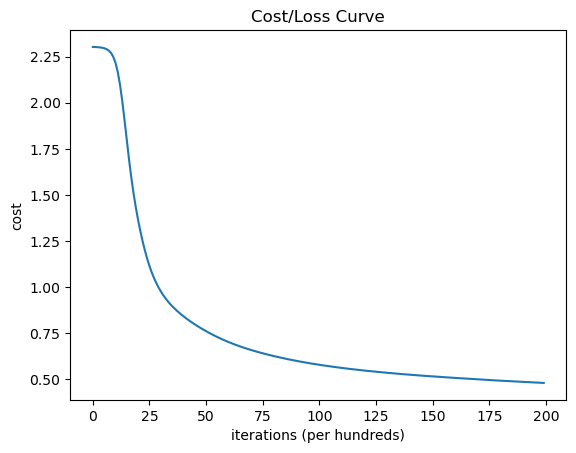

In [31]:
plotLearningCurve_hog(model_hog)

In [32]:
accuracy_hog = accuracy_score(y_test, y_prediction_test_hog)
print("Accuracy on test dataset:", accuracy_hog)

Accuracy on test dataset: 0.8


[[47  1  0  0  1  0  0  1  0  0]
 [ 0 44  0  0  0  1  3  0  0  2]
 [ 0  0 44  0  6  0  0  0  0  0]
 [ 0  0  0 48  0  0  1  0  1  0]
 [ 0  0 10  0 32  4  4  0  0  0]
 [ 0  1  0  0 12 25  8  1  0  3]
 [ 1  2  1  1  6  8 29  1  1  0]
 [ 3  0  0  0  0  0  0 46  0  1]
 [ 0  0  1  3  0  1  0  0 45  0]
 [ 2  1  1  0  2  0  3  0  1 40]]


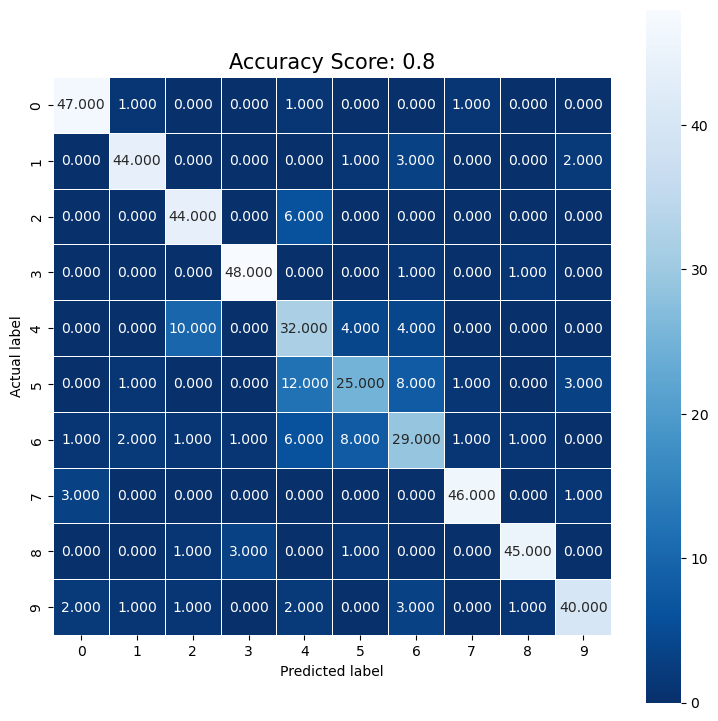

In [33]:
# plot the confusion matrix
cm_hog  = metrics.confusion_matrix(y_test, y_prediction_test_hog)
print(cm_hog)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm_hog, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_hog)
plt.title(all_sample_title, size = 15);

In [34]:
# Display some classification result on test samples
images_hog = []
pred_label_hog = []
true_label_hog = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  H2 = X_test_hog[:, i].reshape(-1, 1)
  prediction_hog = predict(model_hog["params"], H2)[0]
  label_hog = labelName[prediction_hog]
  orig_label_hog = labelName[y_test[i]]
  image = X_test[i]
  image = cv2.merge([image] * 3)
  image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

  # cv2.putText(image, f"Predicted Label: {label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 0), 2)
  # cv2.putText(image, f"True Label: {orig_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 0), 2)
    
  images_hog.append(images_hog)
  pred_label_hog.append(label_hog)
  true_label_hog.append(orig_label_hog)

In [ ]:
np.shape(images_hog[1])

In [ ]:
## Display the classification results
#Plot the image and the predicted labels
fig_hog = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(images_hog[0])
ax1.set_title(f"Prediction: {pred_label_hog[0]} | True: {true_label_hog[0]}")
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(images_hog[1])
ax2.set_title(f"Prediction: {pred_label_hog[1]} | True: {true_label_hog[1]}")
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(images_hog[2])
ax3.set_title(f"Prediction: {pred_label_hog[2]} | True: {true_label_hog[2]}")
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(images_hog[3])
ax4.set_title(f"Prediction: {pred_label_hog[3]} | True: {true_label_hog[3]}")
ax4.axis("off")
plt.show()

In [ ]:
print("Test Accuracy: ", accuracy_score(y_test, y_prediction_test_hog))

print(classification_report(y_test, y_prediction_test_hog, target_names=labelName))

# Assessment Task 1
## Section 2(c): ANN Classifier with RAW PIXELS (rawpxl)
### 1. Extract files and Install all required dependencies and 

In [ ]:
X_train, y_train = load_dataset('./output/train')
X_test, y_test = load_dataset('./output/test')
X_val, y_val = load_dataset('./output/val')

In [ ]:
X_train_rawpxl = X_train.T
X_test_rawpxl = X_test.T
X_val_rawpxl = X_val.T

In [ ]:
print(np.shape(X_train_rawpxl))
print(np.shape(X_test_rawpxl))
print(np.shape(X_val_rawpxl))

In [ ]:
mean = np.mean(X_train_rawpxl, axis=1, keepdims=True)
std = np.std(X_train_rawpxl, axis=1, keepdims=True) + 1e-7

X_train_rawpxl = (X_train_rawpxl - mean) / std
X_test_rawpxl  = (X_test_rawpxl - mean) / std

In [ ]:
# Normalise the X_test and X_train values (in the section after img = img / 255.0 and before reshaping the 28,28 image into 784)

model_rawpxl = fit(X_train_rawpxl, y_train, epochs=2000, learning_rate=0.5, show_cost=True)

## Retrieve w and b from the trained model for prediction
y_prediction_test_rawpxl = predict(model_rawpxl["params"], X_test_rawpxl)

%time
## Call predict() to test the samples in testset
train_accuracy_rawpxl = np.mean(y_prediction_test_rawpxl == y_test) * 100
print(f"train accuracy: {train_accuracy_rawpxl:.2f} %")

In [ ]:
def plotLearningCurve_rawpxl(model_rawpxl):
  """
  Helper function to plot the Learning curve

  Argument : model (learned paramenters and costs)
  """

  plt.plot(model_rawpxl["costs"])
  plt.ylabel('cost')
  plt.xlabel('iterations (per hundreds)')
  plt.title("Cost/Loss Curve")
  plt.show()


In [ ]:
plotLearningCurve_rawpxl(model_rawpxl)

In [ ]:
accuracy_rawpxl = accuracy_score(y_test, y_prediction_test_rawpxl)
print("Accuracy on test dataset:", accuracy_rawpxl)

In [ ]:
# plot the confusion matrix
cm_rawpxl  = metrics.confusion_matrix(y_test, y_prediction_test_rawpxl)
print(cm_rawpxl)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm_rawpxl, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy_rawpxl)
plt.title(all_sample_title, size = 15);

In [ ]:
print("X_test shape:", X_test_rawpxl.shape)

In [ ]:
# Display some classification result on test samples
images_rawpxl = []
pred_label_rawpxl = []
true_label_rawpxl = []

for i in np.random.choice(np.arange(0, X_test_rawpxl.shape[1]), size=(16,)):
  # classify the clothing
  image_rawpxl = X_test_rawpxl[:,i].reshape(28, 28)
  sample = X_test_rawpxl[:,i].reshape(-1, 1)
  prediction_rawpxl = predict(model_rawpxl["params"], sample)[0]
  label_rawpxl = labelName[prediction_rawpxl]
  orig_label_rawpxl = labelName[y_test[i]]
    
  images_rawpxl.append(image_rawpxl)
  pred_label_rawpxl.append(label_rawpxl)
  true_label_rawpxl.append(orig_label_rawpxl)

In [ ]:
np.shape(images_rawpxl[1])

In [ ]:
## Display the classification results
#Plot the image and the predicted labels
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(images_rawpxl[0], cmap='gray')
ax1.set_title(f"Prediction: {pred_label_rawpxl[0]} | True: {true_label_rawpxl[0]}")
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(images_rawpxl[1], cmap='gray')
ax2.set_title(f"Prediction: {pred_label_rawpxl[1]} | True: {true_label_rawpxl[1]}")
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(images_rawpxl[2], cmap='gray')
ax3.set_title(f"Prediction: {pred_label_rawpxl[2]} | True: {true_label_rawpxl[2]}")
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(images_rawpxl[3], cmap='gray')
ax4.set_title(f"Prediction: {pred_label_rawpxl[3]} | True: {true_label_rawpxl[3]}")
ax4.axis("off")
plt.show()

In [ ]:
print("Test Accuracy: ", accuracy_score(y_test, y_prediction_test_rawpxl))

print(classification_report(y_test, y_prediction_test_rawpxl, target_names=labelName))